In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import pandas as pd

df = pd.read_csv("Downloads/Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [10]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nNull Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

Shape: (768, 7)

Data Types:
Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object

Null Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Descriptive Statistics:
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                       

In [11]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove completely empty rows
df = df.dropna(how="all")

print("Shape after cleaning:", df.shape)
print("\nColumns:")
print(df.columns)

Shape after cleaning: (740, 7)

Columns:
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [12]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

print(df.dtypes)

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object


In [13]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

region_avg = region_avg.sort_values(ascending=False)

print(region_avg)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


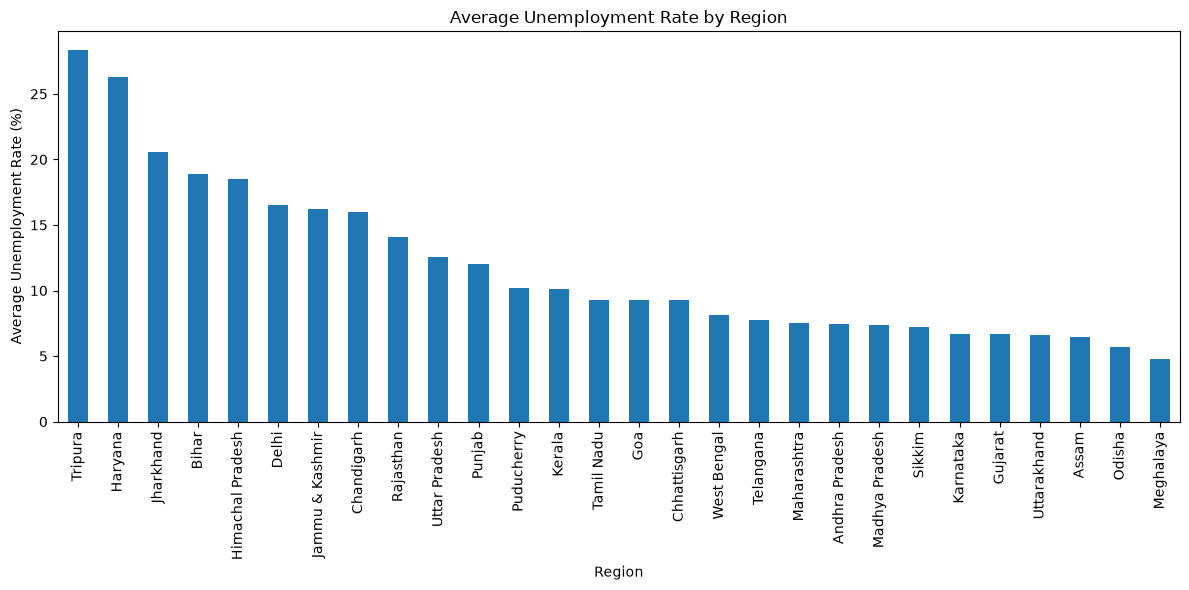

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

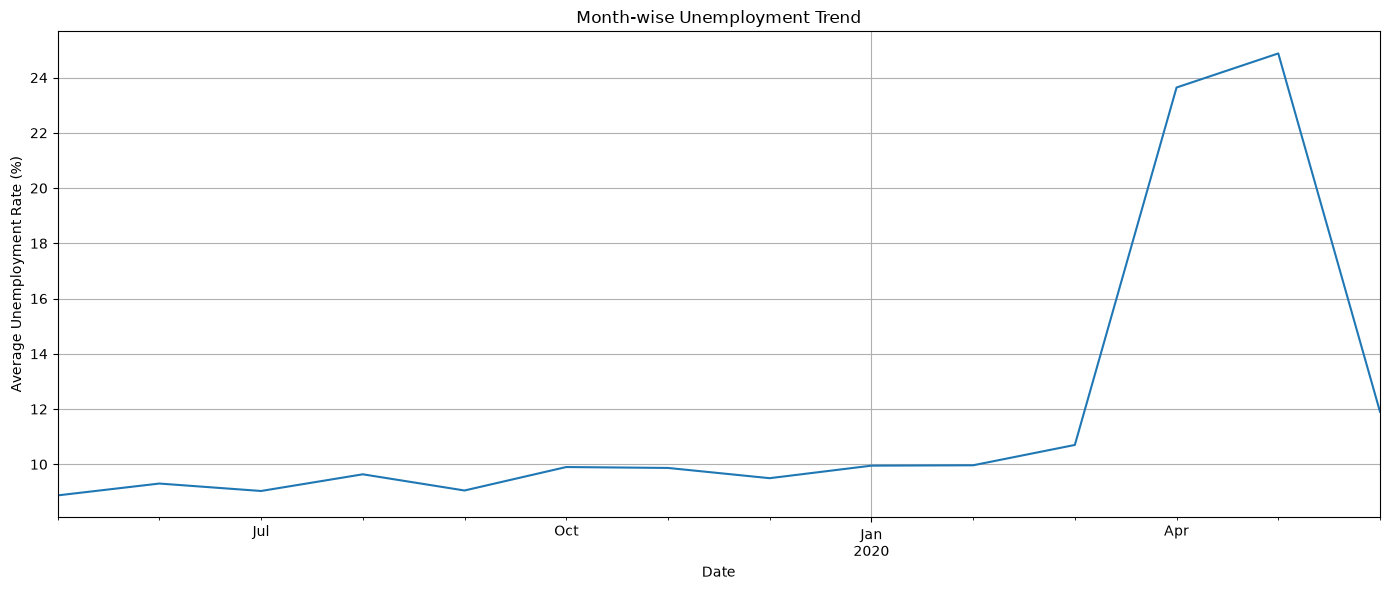

In [15]:
monthly_avg = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(14, 6))

monthly_avg.plot()

plt.title("Month-wise Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid()
plt.tight_layout()
plt.show()

In [16]:
print(df["Region"].unique())

<ArrowStringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str


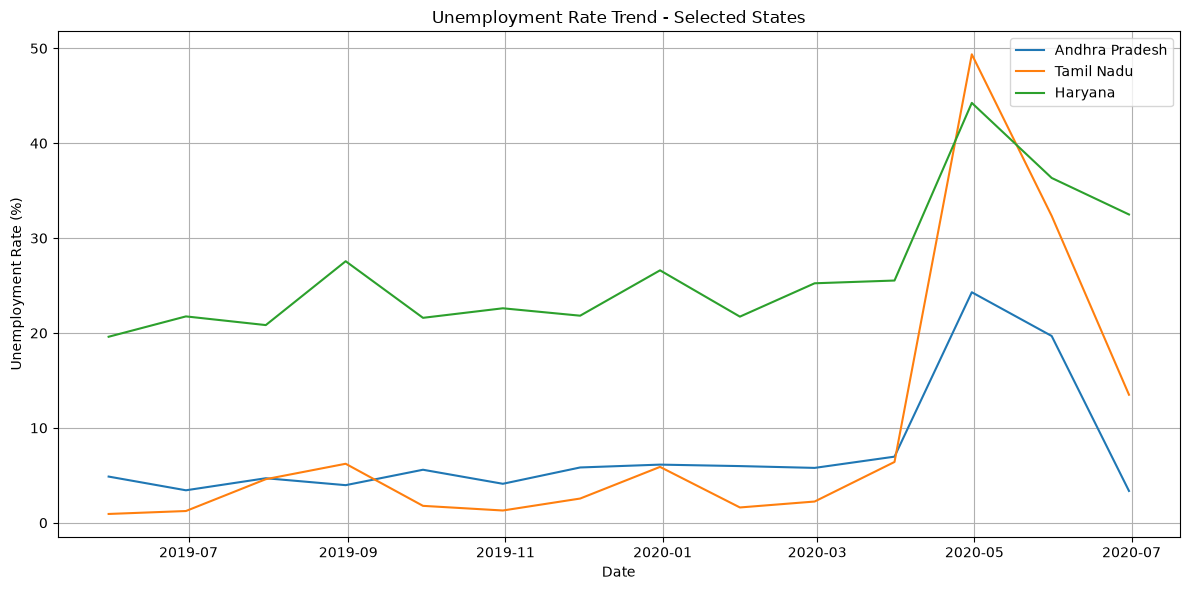

In [17]:
states = ["Andhra Pradesh", "Tamil Nadu", "Haryana"]

plt.figure(figsize=(12, 6))

for state in states:
    temp = df[df["Region"] == state].groupby("Date")["Estimated Unemployment Rate (%)"].mean()
    plt.plot(temp.index, temp.values, label=state)

plt.title("Unemployment Rate Trend - Selected States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

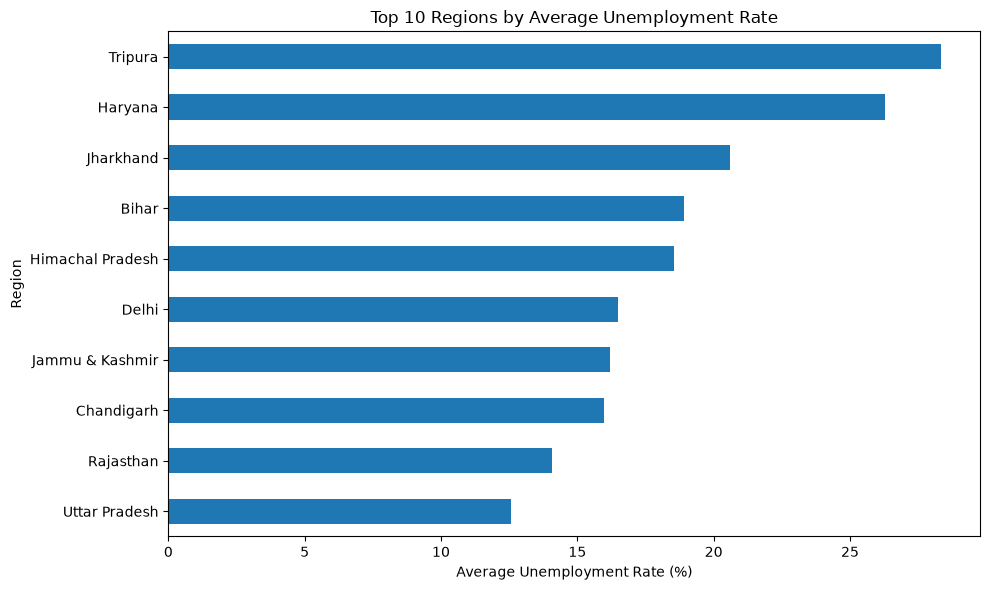

In [18]:
top10 = region_avg.head(10)

plt.figure(figsize=(10, 6))

top10.sort_values().plot(kind="barh")

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

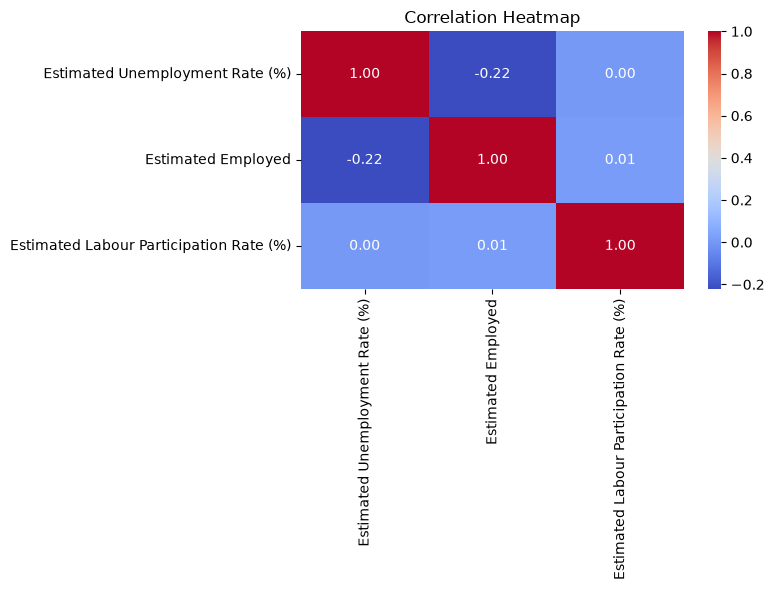

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [20]:
pre_covid = df[
    df["Date"] < "2020-03-01"
]["Estimated Unemployment Rate (%)"].mean()

covid_period = df[
    df["Date"] >= "2020-03-01"
]["Estimated Unemployment Rate (%)"].mean()

print("Pre-COVID Average Unemployment Rate:", round(pre_covid, 2), "%")
print("COVID Period Average Unemployment Rate:", round(covid_period, 2), "%")

Pre-COVID Average Unemployment Rate: 9.51 %
COVID Period Average Unemployment Rate: 17.77 %


## Conclusion

The unemployment analysis was performed using the Unemployment in India dataset.

Key findings:
- The average unemployment rate varied significantly across different regions.
- Tripura had the highest average unemployment rate at 28.35%.
- Meghalaya had the lowest average unemployment rate at 4.80%.
- The unemployment trend showed significant changes over the study period.
- The average unemployment rate before the COVID-19 period was 9.51%.
- During the COVID-19 period, the average unemployment rate increased to 17.77%.
- This shows a significant increase in unemployment during the COVID-19 period.

Overall, the analysis shows that unemployment varied across regions and increased considerably during the COVID-19 period.